In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [3]:
# 훈련세트 테스트세트  분할
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# 이상치 탐지 라이브러리
# 정상데이터 보다 이상치는 더 쉽게 적은 분할로 고립된다
# 랜덤하게 feature 선택 랜덤하게 split value 선택 -> 계속 어떤 데이터가 얼마나 빨리 고립되는가
# 트리 알고리듬, 이상치는 적은 분할회수로 고립, 트리가 깊지 않음
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(random_state=42)
housing_numeric_for_outlier = train_set.drop('ocean_proximity', axis =1).dropna()
housing_numeric_for_outlier
isolation_forest.fit_predict(housing_numeric_for_outlier)

array([-1,  1, -1, ...,  1,  1,  1])

In [4]:
pd.Series(1, index=train_set.index)

14196    1
8267     1
17445    1
14265    1
2271     1
        ..
11284    1
11964    1
5390     1
860      1
15795    1
Length: 16512, dtype: int64

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY


In [6]:
# 훈련세트 테스트세트 분할
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,random_state=42)

# 이상치 탐지 라이브러리
# 정상데이터보다 이상치는 더 쉽게(적은 분할로) 고립된다
# 랜던하게 feature선택 랜덤하게 split value 선택 -> 계속.. 어떤 데이터가 얼마나 빨리 고립되는가
# 트리알고리즘, 이상치는 적은 분할회수로고립, 트리가 깊지 않음
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(random_state=42)
housing_numeric_for_outlier = train_set.drop('ocean_proximity',
                                             axis=1).dropna() # 결측치를 제거해서 원본대비 줄었음
housing_numeric_for_outlier.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0


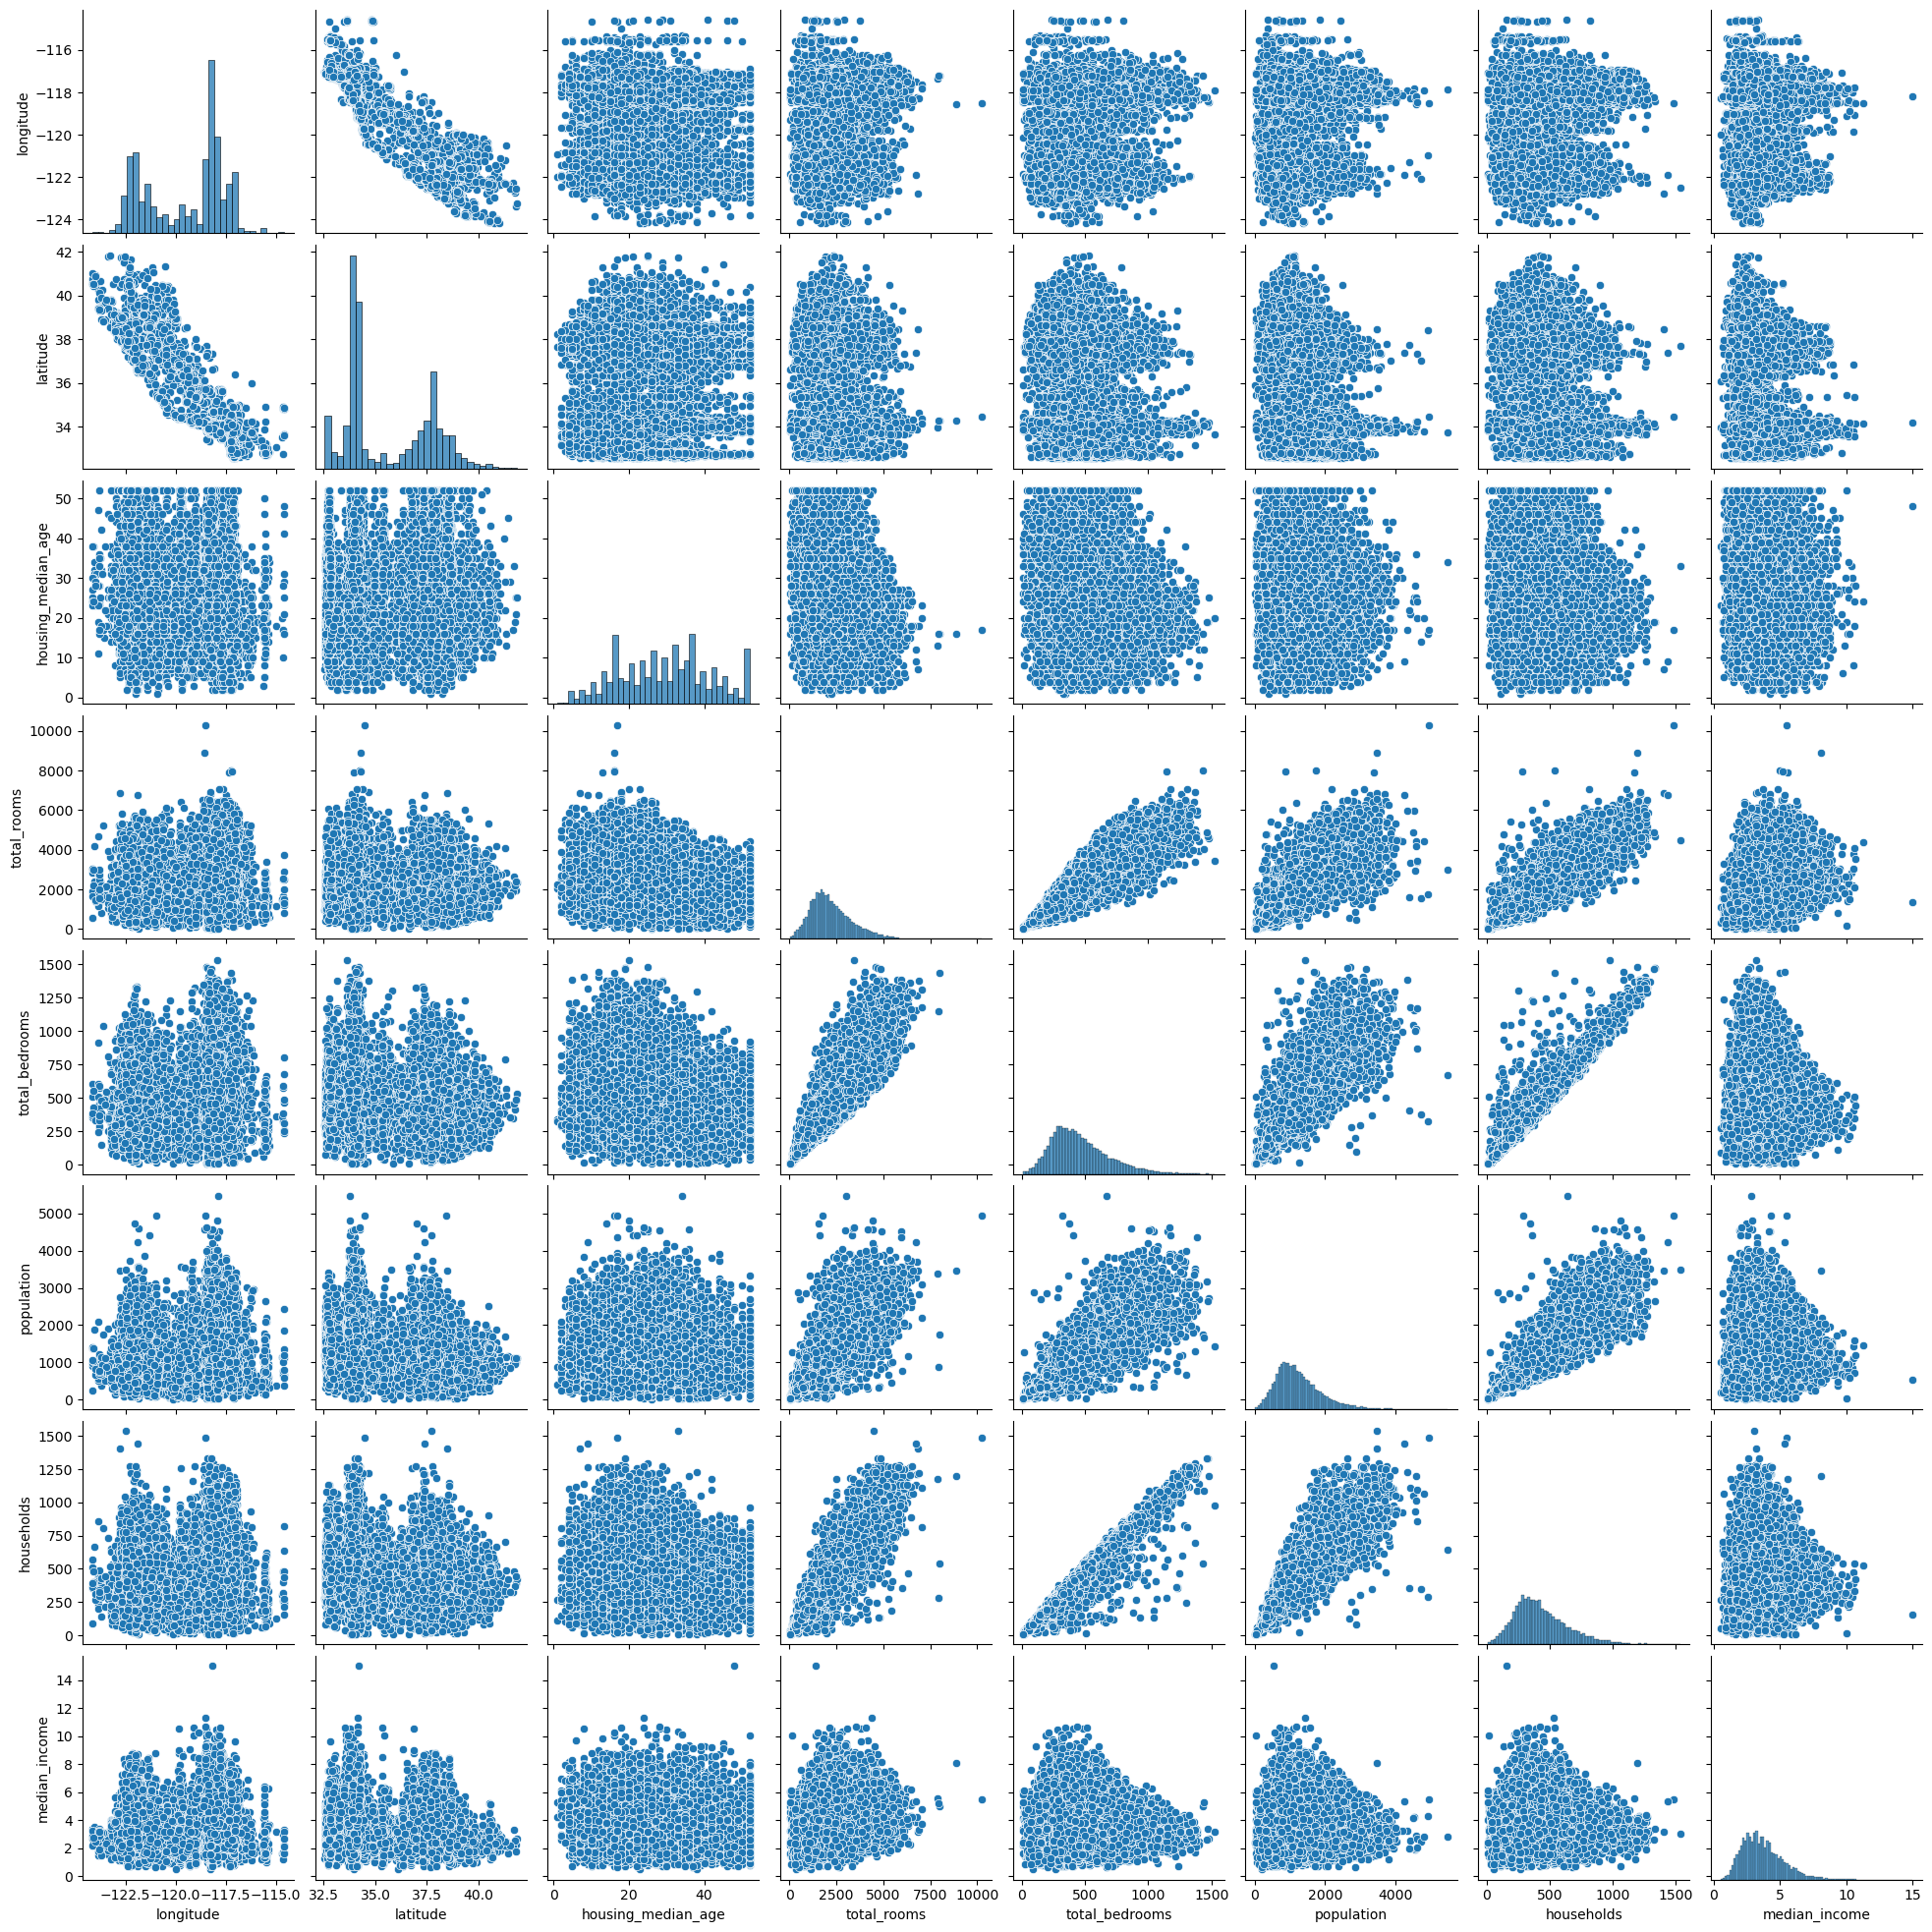

In [11]:
outlier_pred = pd.Series(1,index = train_set.index)
# 결측치 제거로 줄었으니 다시 원래대로 복원(인덱스 번호끼리 맞춤)

outlier_pred.loc[housing_numeric_for_outlier.index] = isolation_forest.fit_predict(housing_numeric_for_outlier)

# 정상 1 이상치 -1
train_set_clean = train_set[outlier_pred ==1]

# x, y 분리
train_set_clean
housing  = train_set_clean.drop(('median_house_value'), axis=1) # 정답제거된 학습용 데이터
housing_label = train_set_clean['median_house_value'].copy() # 정답

# 데이터 분포가 한쪽으로 치우쳐진 즉 꼬리가 긴 왜도를 찾기
import seaborn as sns
sns.pairplot(housing)


In [19]:
import numpy as np
#왜도 컬럼
skewed_attribs =  ['total_rooms','total_bedrooms', 'population','households','median_income']
#수치형 컬럼
num_attribs = ['longitude','latitude','housing_median_age']
# 범주형 컬럼
cat_attribs = ['ocean_proximity']

# 파이프라인
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler',StandardScaler())
])
# 범주형 부분과 최종 파이프라인
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ('num',num_pipeline,num_attribs),
    ('log',log_pipeline,skewed_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

# 모델 선택
from sklearn.ensemble import RandomForestRegressor
full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])
# 훈련
full_pipeline.fit(housing,housing_label)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age']),
                                                 ('log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat', OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('random_forest', RandomForestRegressor(random_state=42))])

In [21]:
full_pipeline.score(test_set.drop('median_house_value',axis=1),
                    test_set['median_house_value'])

0.8089169059009034

In [ ]:
# gridSearchCV를 이용해서 성능을 측정

In [26]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

# gridSearchCV를 이용해서 성능을 측정
# 튜닝 - 모델
param_grid = [
    {'random_forest__n_estimators':[30,100,200], 'random_forest__max_features':[2,4,6]}
]
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(full_pipeline, param_grid=param_grid,cv=3)
grid_search.fit(housing.drop('median_house_value', axis=1), housing['median_house_value'])

import random
random_5 = random.sample(range(len(housing)), 5)

print(f'최고의 파라메터 : {grid_search.best_params_}')
print(f'최고의 점수 : {grid_search.best_score_}')
best_model = grid_search.best_estimator_
predict_value = best_model.predict( housing.iloc[random_5].drop('median_house_value',axis=1) )
print(predict_value)

최고의 파라메터 : {'random_forest__max_features': 6, 'random_forest__n_estimators': 200}
최고의 점수 : 0.8208977973711301
[456732.61 210742.   192741.    89390.   117612.  ]


In [24]:
# cv 파라메터에 들어갈 알고리듬 (폴더객체)
from sklearn.model_selection import KFold
kfold = KFold(shuffle=True)
x = np.arange(10)
for train_idx, val_idx in kfold.split(x):
    print(train_idx, val_idx)

[0 1 2 4 5 6 7 9] [3 8]
[0 1 3 5 6 7 8 9] [2 4]
[2 3 4 5 6 7 8 9] [0 1]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 6 7 8] [5 9]


In [27]:
# 교차검증
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
housing_clean = housing.dropna().copy()
scores = cross_val_score(model , housing_clean.drop(['median_house_value','ocean_proximity'],axis=1) , 
                         housing_clean['median_house_value'] ,cv=5)

In [25]:
# 분류에서 
from sklearn.model_selection import StratifiedGroupKFold    
sk =StratifiedGroupKFold(n_splits=5)    


In [28]:
# cv 파라메터에 들어갈 알고리즘(폴더객체)
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)
x = np.arange(10)
for train_idx, val_idx in kfold.split(x):
    print(train_idx, val_idx)

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [29]:
# 교차검증
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
housing_clean = housing.dropna().copy()
scores = cross_val_score(model , housing_clean.drop(['median_house_value','ocean_proximity'],axis=1) , 
                         housing_clean['median_house_value'] ,cv=kfold)